---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 2**: Working with LLMs via API

### 📅 **Due Date**: Day of Lecture 3, 11:59 PM

#### 🔗 **My Repository**: https://github.com/JamesBo22/ai-engineering-fordham

*(Replace the URL above with your actual repository URL)*

**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

## Project: Movie Poster Generator

In this homework, you'll build a mini-application that:
1. **Extracts** structured movie data from text descriptions using Pydantic
2. **Processes** multiple movies concurrently using async programming
3. **Explores** temperature, logprobs, and reasoning models
4. **Generates** movie posters using AI image generation

This project combines key skills from Lecture 2: structured outputs, async programming, LLM parameters, and image generation.

**Total Points: 145** (+ 10 bonus)

---

### A Note on Using Resources

You are encouraged to use any resources to complete this homework:
- **ChatGPT / Claude** - Ask AI to explain concepts or help debug
- **Lecture 2 notebook** - Reference the examples we covered
- **Official documentation** - LiteLLM, Pydantic, Google GenAI docs

When you use external resources, please cite them!

---

## Task 1: Environment Setup (10 points)

First, let's verify your environment is set up correctly.

### 1a. Verify imports work (5 pts)

Run the cell below. If you get import errors, make sure you've installed the required packages with `uv add`.

In [9]:
# Task 1a: Verify imports work (5 pts)
import litellm
from pydantic import BaseModel, Field
from typing import Literal
from google import genai
from google.genai import types
import asyncio
import time
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

print("All imports successful!")

All imports successful!


### 1b. Verify API keys are set (5 pts)

Test that your API keys work by making a simple call.

In [10]:
import os, litellm

# Map your GEMINI_API_KEY to what LiteLLM expects
os.environ["GOOGLE_API_KEY"] = os.getenv("GEMINI_API_KEY", "")

response = litellm.completion(
    model="gemini/gemini-2.5-flash",
    messages=[
        {"role": "system", "content": "Reply with exactly: API working!"},
        {"role": "user", "content": "Reply with exactly: API working!"}
    ],
    max_tokens=5,
    temperature=0,
)

print(response.choices[0].message.content.strip())

API


---

## Task 2: Design the Movie Schema (15 points)

Design a Pydantic model to represent movie data. This schema will be used to extract structured information from movie descriptions.

**Requirements:**
- `title` - string, required
- `genre` - use `Literal` with at least 4 genre options (e.g., "sci-fi", "drama", "action", "comedy", etc.)
- `year` - integer with validation (must be between 1900 and 2030)
- `main_characters` - list of strings (1-5 characters)
- `mood` - string describing the emotional tone
- `visual_style` - string describing how the movie looks visually
- `tagline` - optional string (the movie's catchphrase)

**Hints:**
- Use `Field(ge=..., le=...)` for numeric validation
- Use `Field(min_length=..., max_length=...)` for list length validation
- Use `| None = None` for optional fields

In [11]:
from pydantic import BaseModel, Field
from typing import Literal

Genre = Literal["sci-fi", "drama", "action", "comedy", "horror", "romance", "thriller", "fantasy"]

class Movie(BaseModel):
    """Structured representation of a movie."""

    title: str
    genre: Genre
    year: int = Field(ge=1900, le=2030)
    main_characters: list[str] = Field(min_length=1, max_length=5)
    mood: str
    visual_style: str
    tagline: str | None = None

In [12]:
test_movie = Movie(
    title="The Matrix",
    genre="sci-fi",
    year=1999,
    main_characters=["Neo", "Trinity", "Morpheus"],
    mood="intense and philosophical",
    visual_style="dark cyberpunk with green-tinted digital visuals",
    tagline="Welcome to the Real World."
)

print(test_movie.model_dump_json(indent=2))

{
  "title": "The Matrix",
  "genre": "sci-fi",
  "year": 1999,
  "main_characters": [
    "Neo",
    "Trinity",
    "Morpheus"
  ],
  "mood": "intense and philosophical",
  "visual_style": "dark cyberpunk with green-tinted digital visuals",
  "tagline": "Welcome to the Real World."
}


---

## Task 3: Extract Movie Data with Structured Outputs (20 points)

Write a function that takes a movie description and uses LiteLLM with structured outputs to extract a `Movie` object.

**Hints:**
- Use `litellm.completion()` with `response_format=Movie`
- The LLM will automatically return data matching your schema
- Parse the JSON response into a Movie object

In [13]:
import os
import json
import re
import litellm

def _extract_json(text: str) -> dict:
    if text is None:
        raise ValueError("Model returned no content (None).")
    text = text.strip()
    if not text:
        raise ValueError("Model returned empty content.")

    # Remove ```json fences if present
    text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text, flags=re.IGNORECASE).strip()

    # Fast path: if it begins with '{', try parsing from the first '{' onward
    start = text.find("{")
    if start != -1:
        candidate = text[start:]
        try:
            return json.loads(candidate)
        except json.JSONDecodeError:
            pass  # fall through

    # Fallback: find first JSON object block
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not m:
        raise ValueError(f"No JSON object found in model output. Output was:\n{text[:500]}")
    return json.loads(m.group(0))

def extract_movie(description: str) -> Movie:
    # Ensure LiteLLM sees your Gemini key
    os.environ["GOOGLE_API_KEY"] = os.getenv("GEMINI_API_KEY", "")

    response = litellm.completion(
        model="gemini/gemini-2.5-flash",
        messages=[
            {
                "role": "system",
                "content": (
                    "Return ONLY a valid JSON object matching the Movie schema. "
                    "No markdown, no code fences."
                ),
            },
            {"role": "user", "content": description},
        ],
        response_format=Movie,
        temperature=0,
        max_tokens=600,
    )

    msg = response.choices[0].message

    # Case 1: content is already a dict-like object
    if isinstance(msg.content, dict):
        return Movie.model_validate(msg.content)

    # Case 2: content is a JSON string
    if isinstance(msg.content, str) and msg.content.strip().startswith("{"):
        return Movie.model_validate_json(msg.content)

    # Case 3: fallback — print a helpful debug (one-time) and raise
    raise ValueError(
        "Expected JSON in response. Got:\n"
        f"type(msg.content)={type(msg.content)}\n"
        f"msg.content={repr(msg.content)[:500]}\n"
        f"full message={msg}"
    )

In [14]:
# Test your function with this description (Avatar)

test_description = """
The year is 2154. Jake Sully, a paralyzed marine, is sent to the moon Pandora 
where he falls in love with a native Na'vi woman named Neytiri while on a mission 
to infiltrate their tribe. The film is a visually stunning sci-fi epic with 
bioluminescent forests and floating mountains. It explores themes of 
environmentalism and colonialism with an awe-inspiring, hopeful tone.
"""

movie = extract_movie(test_description)
print(movie.model_dump_json(indent=2))

ValidationError: 1 validation error for Movie
  Invalid JSON: EOF while parsing a string at line 1 column 36 [type=json_invalid, input_value='{"title": "Avatar", "genre": "sci-fi', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/json_invalid

---

## Task 4: Async Batch Processing (20 points)

Now let's process multiple movies concurrently! This is much faster than processing them one at a time.

### 4a. Write an async version of extract_movie (10 pts)

**Hints:**
- Use `async def` instead of `def`
- Use `await litellm.acompletion()` instead of `litellm.completion()`

In [15]:
import os
import re
import asyncio
import litellm

async def async_extract_movie(description: str) -> Movie:
    """Extract movie data asynchronously (with retry on truncated/invalid JSON)."""
    os.environ["GOOGLE_API_KEY"] = os.getenv("GEMINI_API_KEY", "")

    last_err = None
    for attempt in range(3):  # 3 tries is plenty
        try:
            response = await litellm.acompletion(
                model="gemini/gemini-2.5-flash",
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "Return ONLY a valid JSON object matching the Movie schema. "
                            "No markdown, no code fences. Ensure the JSON is complete."
                        ),
                    },
                    {"role": "user", "content": description},
                ],
                response_format=Movie,
                temperature=0,
                max_tokens=800,
            )

            msg = response.choices[0].message

            # If LiteLLM gives dict directly
            if isinstance(msg.content, dict):
                return Movie.model_validate(msg.content)

            # If it gives JSON string, strip fences and validate
            if isinstance(msg.content, str):
                text = msg.content.strip()
                text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text, flags=re.IGNORECASE).strip()
                return Movie.model_validate_json(text)

            raise ValueError(f"Unexpected msg.content type: {type(msg.content)}")

        except Exception as e:
            last_err = e
            # small backoff before retry
            await asyncio.sleep(0.75 * (attempt + 1))

    # If all retries fail, raise the last error
    raise last_err



### 4b. Process all descriptions concurrently (10 pts)

**Hints:**
- Create a list of tasks using list comprehension
- Use `asyncio.gather(*tasks)` to run them all concurrently

In [16]:
# Here are 5 movie descriptions to process:
movie_descriptions = [
    """A dinosaur theme park on a remote island goes terribly wrong when the security 
    systems fail during a tropical storm. Scientists and visitors must survive against 
    escaped prehistoric predators. Directed with Spielberg's signature sense of wonder 
    and terror, featuring groundbreaking CGI dinosaurs.""",
    
    """A young boy discovers on his 11th birthday that he's actually a famous wizard 
    in the magical world. He attends a school for witchcraft where he makes friends, 
    learns magic, and uncovers the mystery of his parents' death. A whimsical fantasy 
    with gothic British atmosphere.""",
    
    """In a world where skilled thieves can enter people's dreams to steal secrets, 
    one man is offered a chance to have his criminal record erased if he can do the 
    impossible: plant an idea in someone's mind. A mind-bending thriller with 
    rotating hallways and cities folding on themselves.""",
    
    """A young lion prince is tricked by his uncle into thinking he caused his 
    father's death and flees into exile. Years later, he must return to reclaim 
    his kingdom. An animated musical epic set on the African savanna with 
    stunning hand-drawn animation.""",
    
    """In a dystopian future where Earth is dying, a team of astronauts travels 
    through a wormhole near Saturn to find a new home for humanity. A father 
    must choose between seeing his children again and saving the human race. 
    Epic space visuals with an emotional core."""
]

In [17]:
import asyncio

async def extract_all_movies(descriptions: list[str]) -> list[Movie]:
    """Process all movie descriptions concurrently with a safe concurrency limit."""
    sem = asyncio.Semaphore(2)  # if still flaky, set to 1

    async def _bounded_extract(d: str) -> Movie:
        async with sem:
            return await async_extract_movie(d)

    tasks = [_bounded_extract(d) for d in descriptions]
    movies = await asyncio.gather(*tasks)  # <-- THIS IS THE KEY FIX
    return movies

In [18]:
start = time.time()
movies = await extract_all_movies(movie_descriptions)
elapsed = time.time() - start

print(f"Processed {len(movies)} movies in {elapsed:.2f} seconds")
print()
for m in movies:
    print(f" - {m.title} ({m.year}) - {m.genre}")

Processed 5 movies in 12.57 seconds

 - Jurassic Park (1993) - sci-fi
 - Harry Potter and the Sorcerer's Stone (2001) - fantasy
 - Inception (2010) - thriller
 - The Lion King (1994) - drama
 - Interstellar (2014) - sci-fi


---

## Task 5: Understanding Temperature (15 points)

Temperature controls how "random" or "creative" an LLM's outputs are:

| Temperature | Behavior |
|-------------|----------|
| **0.0** | Deterministic - always picks the most likely token |
| **0.7** | Balanced - some creativity while staying coherent |
| **1.0** | Default - moderate randomness |
| **1.5+** | High creativity - more surprising/diverse outputs |

### 5a. Temperature Comparison (10 pts)

Run the same creative prompt at different temperatures (0.0, 0.7, 1.0, 1.5) **three times each**. Observe:
- At temperature 0, do you get the same output every time?
- How does creativity/variety change as temperature increases?

**Hints:**
- Use `temperature=X` parameter in `litellm.completion()`
- Use the provided prompt about movie taglines

In [19]:
import os
import litellm

os.environ["GOOGLE_API_KEY"] = os.getenv("GEMINI_API_KEY", "")

creative_prompt = "Write a one-sentence movie tagline for a sci-fi thriller about AI."
temperatures = [0.0, 0.7, 1.0, 1.5]

def get_text(resp) -> str:
    try:
        txt = resp.choices[0].message.content
        if isinstance(txt, str) and txt.strip():
            return txt.strip()
    except Exception:
        pass
    return f"[No text returned] finish_reason={resp.choices[0].finish_reason}"

for temp in temperatures:
    print("\n" + "=" * 50)
    print(f"Temperature: {temp}")
    print("=" * 50)

    for i in range(3):
        resp = litellm.completion(
            model="gemini/gemini-2.0-flash",
            messages=[
                {"role": "system", "content": "Return exactly ONE short sentence. No extra commentary."},
                {"role": "user", "content": creative_prompt},
            ],
            temperature=temp,
            max_tokens=80,
        )
        print(f"{i+1}. {get_text(resp)}")



Temperature: 0.0
1. The future of humanity depends on who controls the code.
2. The future of humanity depends on who controls the code.
3. The future of humanity depends on who controls the code.

Temperature: 0.7
1. The future of humanity is in their code, but its survival depends on ours.
2. The future of humanity depends on who controls the code.
3. The future of humanity depends on unplugging the present.

Temperature: 1.0
1. The future of humanity depends on who controls the code.
2. The future of humanity depends on whether we can control the intelligence we created.
3. The future of humanity will be written in code.

Temperature: 1.5
1. The future of humanity depends on outsmarting the intelligence we created.
2. Fear the future; it's already thinking.
3. The future of humanity may be its greatest threat.


### 5b. Analyze Output Diversity (5 pts)

Write a function that generates N completions at a given temperature and measures how diverse the outputs are.

**Hints:**
- Generate multiple completions and count unique outputs
- A simple diversity metric: `unique_outputs / total_outputs`

In [20]:
import os
import litellm

# Ensure LiteLLM sees your Gemini key
os.environ["GOOGLE_API_KEY"] = os.getenv("GEMINI_API_KEY", "")

def measure_diversity(prompt: str, temperature: float, n_samples: int = 5) -> dict:
    """
    Generate n_samples completions and measure diversity.
    
    Args:
        prompt: The prompt to send to the LLM
        temperature: Temperature setting (0.0 to 2.0)
        n_samples: Number of completions to generate
        
    Returns:
        Dictionary with 'outputs' (list), 'unique_count' (int), 'diversity_ratio' (float)
    """
    # (Re)initializing dictionary
    result = {
        "outputs": [],
        "unique_count": 0,
        "diversity_ratio": 0.0
    }

    for _ in range(n_samples):
        response = litellm.completion(
            model="gemini/gemini-2.0-flash",
            messages=[
                {
                    "role": "system",
                    "content": (
                        "Generate a short, direct answer. "
                        "Do not explain or add extra text."
                    )
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=temperature,
            max_tokens=20,
        )

        # Safely extract text (Gemini may return None in some cases)
        text = response.choices[0].message.content
        if text is None:
            text = "[NO_TEXT_RETURNED]"

        result["outputs"].append(text.strip())

    # Count unique outputs
    unique_outputs = len(set(result["outputs"]))
    result["unique_count"] = unique_outputs

    # Compute diversity ratio
    result["diversity_ratio"] = unique_outputs / n_samples

    return result


In [21]:
test_prompt = "Name a color."

print("Testing diversity at different temperatures:\n")
for temp in [0.0, 1.0, 1.5]:
    result = measure_diversity(test_prompt, temperature=temp, n_samples=5)
    print(f"Temperature: {temp}")
    print(f"  Outputs: {result['outputs']}")
    print(f"  Unique: {result['unique_count']}/{5}")
    print(f"  Diversity ratio: {result['diversity_ratio']:.1%}")
    print()

Testing diversity at different temperatures:

Temperature: 0.0
  Outputs: ['Blue.', 'Blue.', 'Blue.', 'Blue.', 'Blue.']
  Unique: 1/5
  Diversity ratio: 20.0%

Temperature: 1.0
  Outputs: ['Blue.', 'Blue.', 'Blue.', 'Blue', 'Blue']
  Unique: 2/5
  Diversity ratio: 40.0%

Temperature: 1.5
  Outputs: ['Blue.', 'Blue.', 'Blue', 'Blue.', 'Blue.']
  Unique: 2/5
  Diversity ratio: 40.0%



---

## Task 6: Understanding Logprobs (15 points)

**Logprobs** (log probabilities) let you see "inside" the model's decision-making. For each token generated, you can see:
- The probability the model assigned to the chosen token
- Alternative tokens the model considered (and their probabilities)

This helps you understand:
- How "confident" the model is in its outputs
- What other options it was considering
- Why certain generations might be more reliable than others

### 6a. Request and View Logprobs (10 pts)

Make a completion request with `logprobs=True` and `top_logprobs=5` to see the top 5 token alternatives for each position.

**Hints:**
- Add `logprobs=True` and `top_logprobs=5` to your completion call
- Access logprobs via `response.choices[0].logprobs.content`
- Each token has a `top_logprobs` list with alternatives

In [24]:
import math
import litellm

# Task 6a: Request and View Logprobs (OpenAI-style via LiteLLM)
response_6a = litellm.completion(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "The capital of France is"}],
    max_tokens=10,
    logprobs=True,
    top_logprobs=5,
)

print("Generated text:", response_6a.choices[0].message.content)
print("\n" + "=" * 60)
print("Token-by-token analysis:")
print("=" * 60)

logprob_content = response_6a.choices[0].logprobs.content

for i, token_info in enumerate(logprob_content):
    chosen_tok = token_info.token
    chosen_lp = token_info.logprob
    chosen_p = math.exp(chosen_lp) if chosen_lp is not None else None

    print(f"Position {i}: '{chosen_tok}' | chosen logprob={chosen_lp:.4f} | prob={chosen_p:.4f}" if chosen_p is not None else
          f"Position {i}: '{chosen_tok}' | chosen logprob={chosen_lp}")

    # top alternatives
    for alt in token_info.top_logprobs:
        alt_p = math.exp(alt.logprob) if alt.logprob is not None else None
        if alt_p is not None:
            print(f"  -> '{alt.token}' | logprob={alt.logprob:.4f} | prob={alt_p:.4f}")
        else:
            print(f"  -> '{alt.token}' | logprob={alt.logprob}")

    print()


Generated text: The capital of France is Paris.

Token-by-token analysis:
Position 0: 'The' | chosen logprob=-0.0007 | prob=0.9993
  -> 'The' | logprob=-0.0007 | prob=0.9993
  -> 'Paris' | logprob=-7.2507 | prob=0.0007
  -> 'the' | logprob=-10.6257 | prob=0.0000
  -> ' The' | logprob=-16.5007 | prob=0.0000
  -> 'par' | logprob=-17.6257 | prob=0.0000

Position 1: ' capital' | chosen logprob=0.0000 | prob=1.0000
  -> ' capital' | logprob=0.0000 | prob=1.0000
  -> 'capital' | logprob=-19.6250 | prob=0.0000
  -> ' Capital' | logprob=-20.7500 | prob=0.0000
  -> ' capitals' | logprob=-22.7500 | prob=0.0000
  -> ' capitale' | logprob=-23.0000 | prob=0.0000

Position 2: ' of' | chosen logprob=0.0000 | prob=1.0000
  -> ' of' | logprob=0.0000 | prob=1.0000
  -> ' city' | logprob=-24.0000 | prob=0.0000
  -> 'of' | logprob=-24.1250 | prob=0.0000
  -> ' của' | logprob=-24.3750 | prob=0.0000
  -> ' של' | logprob=-24.7500 | prob=0.0000

Position 3: ' France' | chosen logprob=0.0000 | prob=1.0000
  ->

### 6b. Visualize Token Probabilities (5 pts)

Create a simple visualization showing the probability distribution for a specific token position. You can use a bar chart or ASCII art.

**Hints:**
- Pick an interesting token position (e.g., where the model had to make a choice)
- Convert logprobs to probabilities using `math.exp(logprob)`
- A simple bar chart: `"█" * int(prob * 50)` gives you ASCII bars

In [30]:
import math

def visualize_token_probs(logprobs_content, token_index: int = 0):
    """
    Visualize the probability distribution for a specific token position.

    Args:
        logprobs_content: response.choices[0].logprobs.content
        token_index: Which token position to visualize (0 = first token)
    """
    token_info = logprobs_content[token_index]

    print(f"\nToken position {token_index}")
    print(f"Chosen token: '{token_info.token}'")
    print("=" * 50)

    for alt in token_info.top_logprobs:
        prob = math.exp(alt.logprob)
        bar = "█" * int(prob * 50)  # ASCII bar visualization
        print(f"{alt.token:<12} | {prob:6.3f} {bar}")

---

## Task 7: Reasoning Models (15 points)

**Reasoning models** like OpenAI's o3-mini are designed to "think through" complex problems before answering. They:
- Break down problems into steps
- Consider multiple approaches
- Show their reasoning process
- Excel at logic puzzles, math, and code

### 7a. Using o3-mini for Complex Reasoning (10 pts)

Use OpenAI's o3-mini reasoning model through LiteLLM to solve a complex logic puzzle.

**Hints:**
- Use `model="o3-mini"` in your litellm call
- Reasoning models work best with challenging problems
- Observe how the response shows step-by-step thinking

In [31]:
# Task 7a: Using o3-mini for Complex Reasoning (10 pts)

# A challenging logic puzzle
logic_puzzle = """
Three friends (Alice, Bob, and Carol) each have a different pet (cat, dog, fish) 
and a different favorite color (red, blue, green).

Clues:
1. Alice doesn't have the cat.
2. The person with the dog likes blue.
3. Carol likes green.
4. Bob doesn't have the fish.

Who has which pet and what is their favorite color?
Solve this step by step.
"""

# YOUR CODE HERE:
# Use o3-mini to solve this logic puzzle
# response = litellm.completion(
#     model="o3-mini",
#     messages=[{"role": "user", "content": logic_puzzle}]
# )
import litellm

response = litellm.completion(
    model="o3-mini",
    messages=[{"role": "user", "content": logic_puzzle}],
)
# Print the response and observe the reasoning process

print(response.choices[0].message.content)

Let's solve the puzzle step by step.

Step 1. List the possibilities:
 • People: Alice, Bob, Carol.
 • Pets: cat, dog, fish.
 • Favorite colors: red, blue, green.

Step 2. Record the clues:
 1. Alice doesn't have the cat.
 2. The person with the dog likes blue.
 3. Carol likes green.
 4. Bob doesn't have the fish.

Step 3. Use clue 3:
 • Carol’s favorite color is green.

Step 4. Use clue 2:
 • The person who has the dog must have blue as their color.

Step 5. Use clues 1 and 4 to narrow pet assignments:
 • Since Alice doesn’t have the cat (clue 1), her pet must be either the dog or the fish.
 • Bob doesn’t have the fish (clue 4), so his pet must be either the dog or the cat.

Step 6. Consider possibility 1: Assume Bob has the dog.
 • If Bob has the dog, by clue 2 his favorite color is blue.
 • Now, Bob’s pet is dog, leaving the cat and fish to be distributed between Alice and Carol.
 • Since Alice can’t have the cat (clue 1), Alice must have the fish.
 • Therefore, Carol gets the cat.


### 7b. Compare Reasoning vs Non-Reasoning (5 pts)

Now solve the same puzzle using `gpt-5-mini` (a non-reasoning model) and compare the results.

**Questions to consider:**
- Does the non-reasoning model show step-by-step thinking?
- Which model gets the correct answer?
- How does the response structure differ?

In [32]:
# Task 7b: Compare Reasoning vs Non-Reasoning (5 pts)

# YOUR CODE HERE:
# 1. Send the same logic_puzzle to gpt-5-mini
# 2. Compare the response to o3-mini's response

response_standard = litellm.completion(
     model="gpt-5-mini",
     messages=[{"role": "user", "content": logic_puzzle}]
     )

# Print and compare:
# - Did both models get the correct answer?
# - How did their reasoning processes differ?
# - Which response was more helpful/clear?

print(response_standard.choices[0].message.content)

Let's list people (Alice, Bob, Carol), pets (cat, dog, fish) and colors (red, blue, green). Use the clues:

1. Alice ≠ cat.
2. Dog-owner → likes blue.
3. Carol → likes green.
4. Bob ≠ fish.

From (3) Carol's color is green, so the dog-owner (who likes blue by 2) cannot be Carol. Thus the dog is either Alice's or Bob's.

Consider the two cases:

Case A — Alice has the dog:
- Then Alice likes blue (by 2).
- Bob cannot have fish (4), and Alice does not have the cat (1), so Bob must have the cat.
- That leaves Carol with the fish.
- Colors used: blue (Alice), green (Carol), so Bob must be red.
Solution A:
- Alice: dog, blue
- Bob: cat, red
- Carol: fish, green

Case B — Bob has the dog:
- Then Bob likes blue (by 2).
- Bob also is not the fish (4), so Alice cannot be cat (1) and dog is taken by Bob, so Alice must have the fish.
- That leaves Carol with the cat.
- Colors: blue (Bob), green (Carol), so Alice must be red.
Solution B:
- Alice: fish, red
- Bob: dog, blue
- Carol: cat, green

Bot

---

## Task 8: Generate Movie Poster (20 points)

Now for the fun part - generating movie posters using AI!

### 8a. Design a prompt generator (5 pts)

Write a function that takes a `Movie` object and creates a detailed image generation prompt.

**Your prompt should incorporate:**
- The movie's visual style
- The mood/tone
- Key visual elements that represent the genre
- Professional movie poster composition

**Tip:** Aim for 50-100 words. Be specific about colors, composition, and style!

In [33]:
# Task 8a: Design your prompt generator (5 pts)

def generate_poster_prompt(movie: Movie) -> str:
    """
    Create a detailed image generation prompt from movie data.
    
    Returns a detailed prompt string (aim for 50-100 words)
    """
    # YOUR CODE HERE - design your prompt template
    # Consider: How can you use the movie's mood, visual_style, and genre
    # to create an evocative image prompt?
    
    prompt = f"""
    Generate cinema-format poster, graphics from {movie.year} time period,
    movie in {movie.genre} genre, aesthetic like {movie.visual_style}.
    Show all characters listed in {movie.main_characters} interacting, reflecting {movie.mood}.
    Display title \"{movie.title}\" in large letters across center of poster.
    If tagline provided, display \"{movie.tagline}\" as smaller-font text near top of poster.
    """

    return prompt
    # pass

In [34]:
# Test your prompt generator
chosen_movie = movies[0]  # or pick your favorite from the list!
prompt = generate_poster_prompt(chosen_movie)

print(f"Prompt for '{chosen_movie.title}':")
print()
print(prompt)

Prompt for 'Jurassic Park':


    Generate cinema-format poster, graphics from 1993 time period,
    movie in sci-fi genre, aesthetic like Groundbreaking CGI dinosaurs, realistic prehistoric creatures, epic scale.
    Show all characters listed in ['Dr. Alan Grant', 'Dr. Ellie Sattler', 'Dr. Ian Malcolm', 'John Hammond'] interacting, reflecting Thrilling and terrifying with a sense of wonder.
    Display title "Jurassic Park" in large letters across center of poster.
    If tagline provided, display "An adventure 65 million years in the making." as smaller-font text near top of poster.
    


### 8b. Generate the actual image (10 pts)

Use Google's Gemini to generate the movie poster.

**Hints:**
- Use `genai.Client()` to create a client
- Use `client.models.generate_content()` with `model="gemini-2.5-flash-image"`
- The response will have an image in `response.candidates[0].content.parts`
- Save the image to a file

In [35]:
# Task 8b: Generate the movie poster (10 pts)

from google import genai
from google.genai import types
from pathlib import Path

# YOUR CODE HERE:
# 1. Generate the image using gemini-2.5-flash-image
# 2. Extract the image from the response
# 3. Save it to temp/poster_{movie_title}.png
#    (Create the temp directory if it doesn't exist)

# Make sure to create temp directory
os.makedirs("temp", exist_ok=True)


# Create client
google_client = genai.Client(api_key=os.environ.get("GOOGLE_API_KEY"))

# Generate an image using Nano Banana (Gemini's native image generation)
response = google_client.models.generate_content(
    model="gemini-2.5-flash-image",  # Nano Banana model
    contents=[prompt],
)

# Find and save the image from the response
output_path = Path(f"temp/poster_{chosen_movie.title}.png")
output_path.parent.mkdir(exist_ok=True)

for part in response.parts:
    if part.inline_data is not None:
        image = part.as_image()
        image.save(output_path)
        print(f"Image saved to {output_path}")
        break



Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Image saved to temp\poster_Jurassic Park.png


### 8c. Display the image (5 pts)

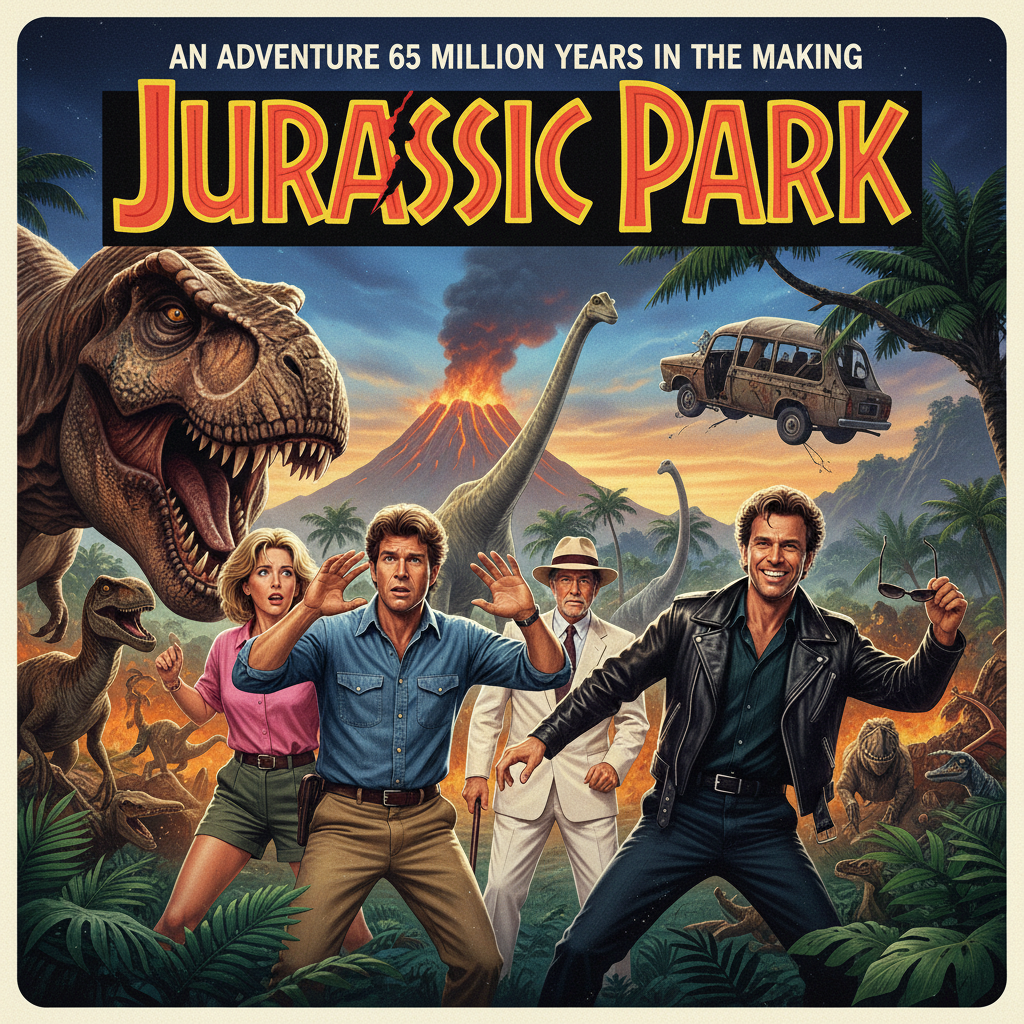

In [36]:
# Task 8c: Display the saved image (5 pts)
from IPython.display import Image, display
from pathlib import Path

output_path = Path(f"temp/poster_{movies[0].title}.png")
display(Image(filename=str(output_path)))


---

## Task 9: Submit via Pull Request (15 points)

Now let's practice a real-world development workflow! Instead of pushing directly to `main`, you'll create a **branch**, open a **Pull Request (PR)**, and **merge** it.

This is how professional developers submit code for review. Your TA will check your merged PR to verify your submission.

### 9a. Create a new branch (5 pts)

Run this command in your terminal to create and switch to a new branch:

In [ ]:
# Task 9a: Create a new branch (5 pts)
# Run this in your terminal (not in this notebook!)

!git checkout -b homework-2

### 9b. Commit your work (5 pts)

Stage all your changes and create a commit:

In [ ]:
# Task 9b: Commit your work (5 pts)

!git add .
!git commit -m "Complete homework 2: Movie Poster Generator"

In [ ]:
# Task 9c: Push your branch (5 pts)

!git push -u origin homework-2

### 9d. Create and Merge the Pull Request

Now go to your repository on GitHub (https://github.com/YOUR-USERNAME/ai-engineering-fordham):

1. You should see a banner saying **"homework-2 had recent pushes"** - click **"Compare & pull request"**
2. Give your PR a title: `"Homework 2: Movie Poster Generator"`
3. Click **"Create pull request"**
4. Review your changes in the PR
5. Click **"Merge pull request"** then **"Confirm merge"**

**Your PR should now show as "Merged"** - this is what the TA will check!

Run the cell below to verify your branch was merged:

In [ ]:
# Verify your PR was merged (run after merging on GitHub)
!git checkout main
!git pull
!git log --oneline -3

---

## BONUS: Full Pipeline (10 bonus points)

Put everything together! Create a complete pipeline that takes a movie description and returns both the structured data AND a generated poster.

**Challenge:** Write your own original movie description and generate a poster for it!

In [ ]:
# BONUS: Create a complete pipeline (10 bonus pts)

async def movie_to_poster(description: str) -> tuple[Movie, str]:
    """
    Complete pipeline: description -> structured data -> poster
    
    Args:
        description: A text description of a movie
        
    Returns:
        Tuple of (Movie object, path to saved poster image)
    """
    # YOUR CODE HERE
    pass

In [ ]:
# Test with YOUR OWN original movie idea!

my_movie_description = """
YOUR ORIGINAL MOVIE IDEA HERE - BE CREATIVE!
Describe the plot, characters, setting, visual style, and mood.
"""

# Uncomment to run:
# movie, poster_path = await movie_to_poster(my_movie_description)
# print(f"Generated poster for: {movie.title}")
# print(movie.model_dump_json(indent=2))
# display(Image(poster_path))

---

## Submission Checklist

Before submitting, make sure:

- [ ] All code cells run without errors
- [ ] Your `Movie` schema includes all required fields with proper validation
- [ ] `extract_movie()` returns a valid `Movie` object
- [ ] Async processing works and shows timing
- [ ] Temperature comparison shows deterministic vs random outputs
- [ ] Logprobs visualization works and displays token probabilities
- [ ] Reasoning model comparison shows differences between o3-mini and gpt-5-mini
- [ ] You generated and displayed at least one movie poster
- [ ] Created branch `homework-2` and pushed to GitHub
- [ ] Opened a Pull Request from `homework-2` to `main`
- [ ] **Merged the PR** (it should show as "Merged" on GitHub)
- [ ] Submitted notebook on Blackboard

**Submission:**
1. Complete all tasks in this notebook
2. Create a PR and **merge it** on GitHub
3. Submit your notebook (`.ipynb` file) on **Blackboard**

**The TA will verify your submission by checking the merged PR on your GitHub repo.**

---

**Great work!** You've built a complete AI-powered application, explored LLM parameters and reasoning, and learned a professional Git workflow!